In [148]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [149]:
file_path = 'wine-red.csv'
data1 = pd.read_csv(file_path)

In [150]:
print(f"Number of duplicate rows: {data1.duplicated().sum()}")

Number of duplicate rows: 240


In [151]:
data = data1.drop_duplicates()
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5


In [152]:
# Check for missing values
missing_values = data.isnull().sum()

# Display missing values
print("Missing values in each column:\n", missing_values)

Missing values in each column:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [153]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000
mean,8.310596,0.529478,0.272333,2.523400,0.088124,15.893304,46.825975,0.996709,3.309787,0.658705,10.432315,5.623252
std,1.736990,0.183031,0.195537,1.352314,0.049377,10.447270,33.408946,0.001869,0.155036,0.170667,1.082065,0.823578
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996700,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.430000,2.600000,0.091000,21.000000,63.000000,0.997820,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


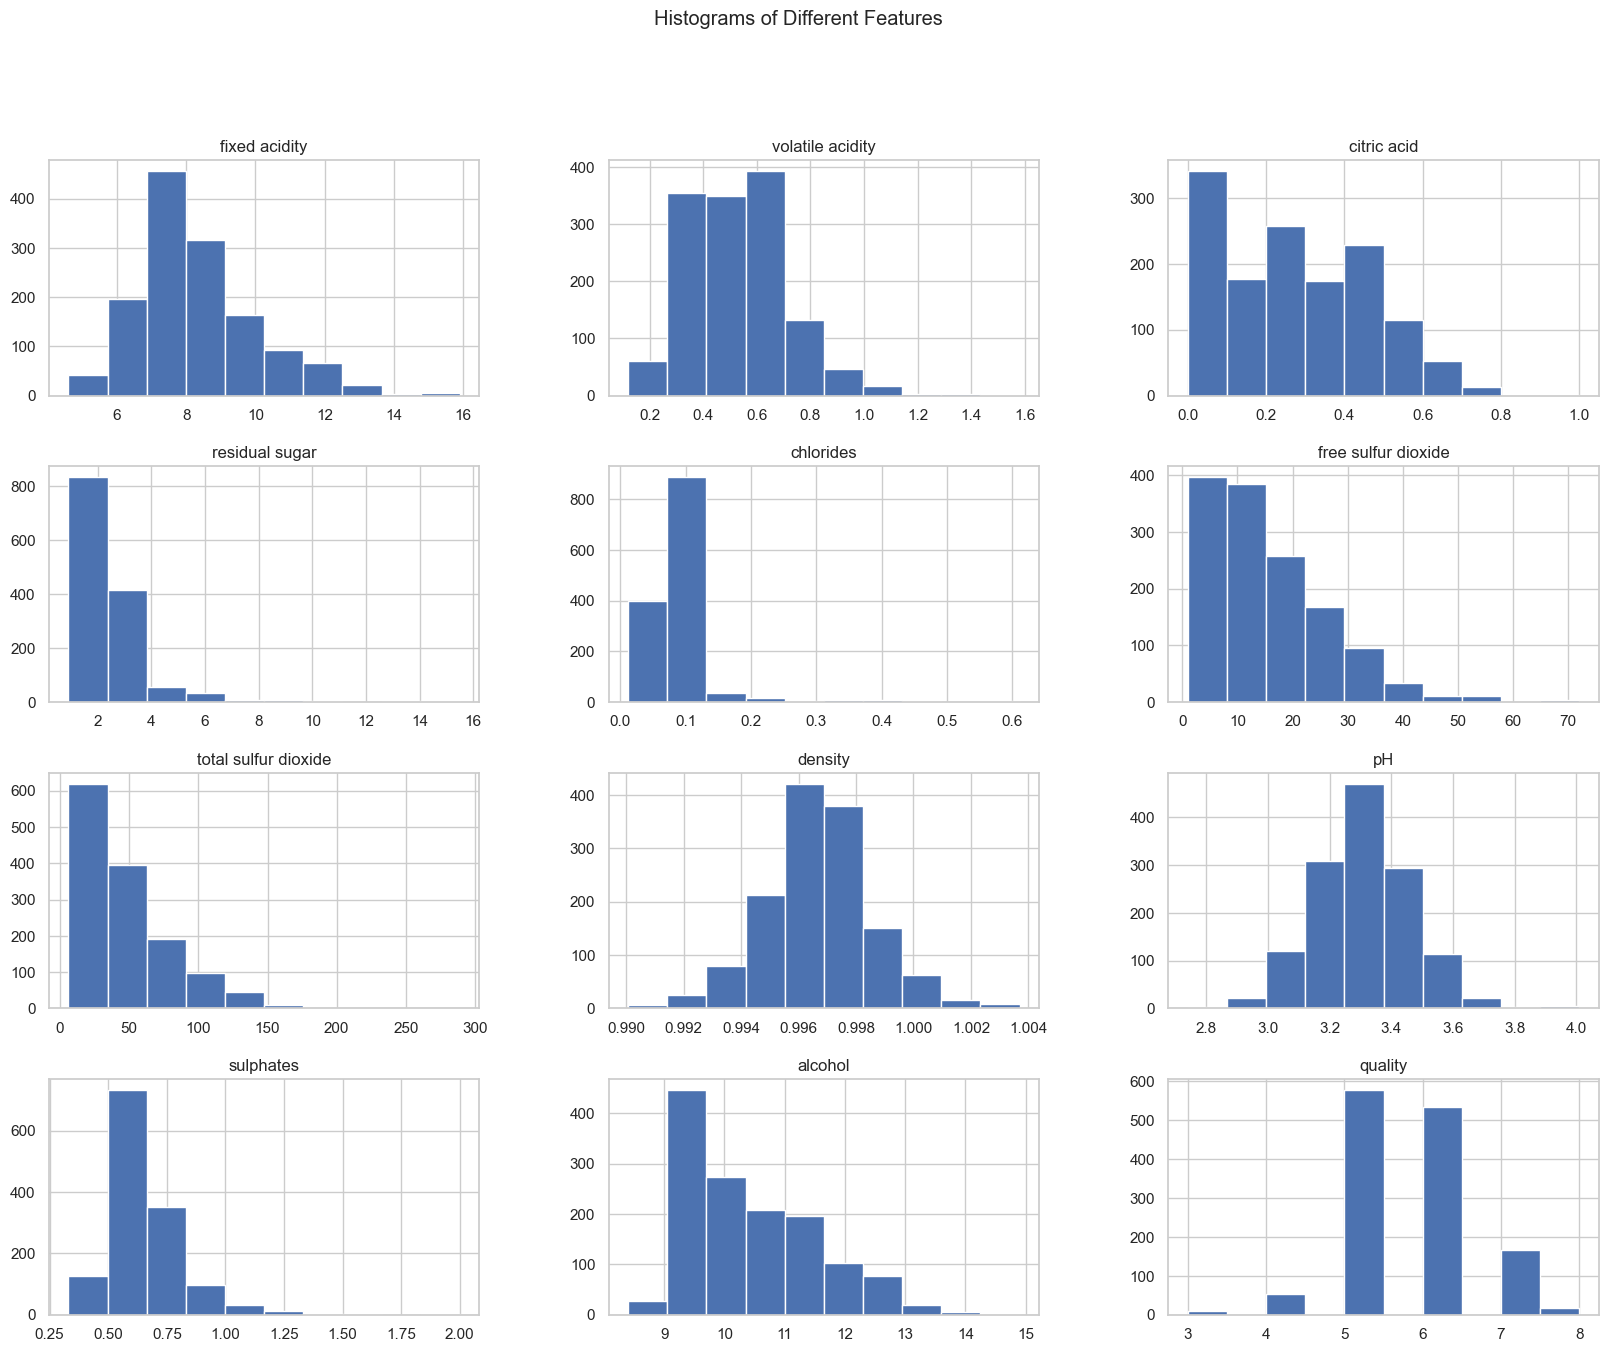

In [154]:
sns.set(style="whitegrid")

# Histograms for each feature
data.hist(bins=10, figsize=(20, 15))
plt.suptitle('Histograms of Different Features')
plt.show()

In [155]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X = data.drop('quality', axis=1)
y = data['quality']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [156]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr, average='weighted')
print(f"Logistic Regression: Accuracy = {accuracy_lr:.4f}, F1 Score = {f1_lr:.4f}")


Logistic Regression: Accuracy = 0.6066, F1 Score = 0.5846


In [157]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn, average='weighted')
print(f"KNN: Accuracy = {accuracy_knn:.4f}, F1 Score = {f1_knn:.4f}")


KNN: Accuracy = 0.5441, F1 Score = 0.5277


In [158]:
from sklearn.svm import SVC

# SVM Linear
svm_linear_model = SVC(kernel="linear", random_state=42)
svm_linear_model.fit(X_train, y_train)
y_pred_svm_linear = svm_linear_model.predict(X_test)

accuracy_svm_linear = accuracy_score(y_test, y_pred_svm_linear)
f1_svm_linear = f1_score(y_test, y_pred_svm_linear, average='weighted')
print(f"SVM Linear: Accuracy = {accuracy_svm_linear:.4f}, F1 Score = {f1_svm_linear:.4f}")


SVM Linear: Accuracy = 0.5956, F1 Score = 0.5378


In [159]:
# SVM Polynomial
svm_poly_model = SVC(kernel="poly", random_state=42)
svm_poly_model.fit(X_train, y_train)
y_pred_svm_poly = svm_poly_model.predict(X_test)

accuracy_svm_poly = accuracy_score(y_test, y_pred_svm_poly)
f1_svm_poly = f1_score(y_test, y_pred_svm_poly, average='weighted')
print(f"SVM Poly: Accuracy = {accuracy_svm_poly:.4f}, F1 Score = {f1_svm_poly:.4f}")


SVM Poly: Accuracy = 0.5919, F1 Score = 0.5663


In [160]:
# SVM RBF
svm_rbf_model = SVC(kernel="rbf", random_state=42)
svm_rbf_model.fit(X_train, y_train)
y_pred_svm_rbf = svm_rbf_model.predict(X_test)

accuracy_svm_rbf = accuracy_score(y_test, y_pred_svm_rbf)
f1_svm_rbf = f1_score(y_test, y_pred_svm_rbf, average='weighted')
print(f"SVM RBF: Accuracy = {accuracy_svm_rbf:.4f}, F1 Score = {f1_svm_rbf:.4f}")


SVM RBF: Accuracy = 0.6434, F1 Score = 0.6201


In [161]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')
print(f"Random Forest: Accuracy = {accuracy_rf:.4f}, F1 Score = {f1_rf:.4f}")


Random Forest: Accuracy = 0.6654, F1 Score = 0.6427


In [162]:
from sklearn.ensemble import ExtraTreesClassifier

# Extra Trees
et_model = ExtraTreesClassifier(random_state=42)
et_model.fit(X_train, y_train)
y_pred_et = et_model.predict(X_test)

accuracy_et = accuracy_score(y_test, y_pred_et)
f1_et = f1_score(y_test, y_pred_et, average='weighted')
print(f"Extra Trees: Accuracy = {accuracy_et:.4f}, F1 Score = {f1_et:.4f}")


Extra Trees: Accuracy = 0.6581, F1 Score = 0.6335


In [163]:
from sklearn.ensemble import BaggingClassifier

# Bagging
bagging_model = BaggingClassifier(random_state=42)
bagging_model.fit(X_train, y_train)
y_pred_bagging = bagging_model.predict(X_test)

accuracy_bagging = accuracy_score(y_test, y_pred_bagging)
f1_bagging = f1_score(y_test, y_pred_bagging, average='weighted')
print(f"Bagging: Accuracy = {accuracy_bagging:.4f}, F1 Score = {f1_bagging:.4f}")


Bagging: Accuracy = 0.6176, F1 Score = 0.5950


In [164]:
from sklearn.tree import DecisionTreeClassifier

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt, average='weighted')
print(f"Decision Tree: Accuracy = {accuracy_dt:.4f}, F1 Score = {f1_dt:.4f}")

Decision Tree: Accuracy = 0.5074, F1 Score = 0.5085


In [165]:
models2 = pd.DataFrame({
    'Model' : ['RF', 'ET', 'DT',  'KNN', 'LR','GBC'],
    'Accuracy' : [rf_acc, et_acc, dt_acc, knn_acc, lr_acc, gbc_acc]
    'F1 Score' : [f1_acc, f1_acc, f1_acc]
})


models2.sort_values(by = 'Score', ascending = True)

,Model,Accuracy,F1 Score
0,Extra Trees,0.4044,0.4488
1,Random Forest,0.4706,0.4544
2,Bagging,0.5956,0.5377
3,SVM RBF,0.4669,0.3881
4,Decision Tree,0.4816,0.4259
5,Logistic Regression,0.6544,0.6332
6,SVM Poly,0.6581,0.6335
7,KNN,0.6250,0.6059
8,SVM Linear,0.5074,0.5077
